In [24]:
import pandas as pd
print("Pandas toolkit ready")

Pandas toolkit ready


In [26]:
data_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(data_url)

print("Data successfully load")

Data successfully load


In [3]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df['Survived']

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [8]:

df[['Age', 'Fare']]

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [27]:

senior_citizens = df[df['Age'] > 60]


senior_citizens.shape

(22, 12)

In [28]:

senior_citizens.to_csv('high_risk_senior_citizens.csv', index=False)

print("Excel/CSV file ready, Abhishek!")

Excel/CSV file ready, Abhishek!


In [15]:
!pip install duckdb
import duckdb
print("Modern Big-Data SQL Engine Ready!")

Modern Big-Data SQL Engine Ready!


In [29]:

duckdb.sql("SELECT COUNT(*) FROM 'risk.csv';").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       594645 │
└──────────────┘



In [30]:

duckdb.sql("""
    SELECT risk_flag, COUNT(*)
    FROM 'risk.csv'
    GROUP BY risk_flag;
""").show()

┌────────────────┬──────────────┐
│   risk_flag    │ count_star() │
│    varchar     │    int64     │
├────────────────┼──────────────┤
│ normal         │       577361 │
│ high magnitude │        17284 │
└────────────────┴──────────────┘



In [31]:

duckdb.sql("""
    SELECT risk_flag, AVG(amount) AS avg_transaction_amount
    FROM 'risk.csv'
    GROUP BY risk_flag;
""").show()

┌────────────────┬────────────────────────┐
│   risk_flag    │ avg_transaction_amount │
│    varchar     │         double         │
├────────────────┼────────────────────────┤
│ normal         │     29.032682611684965 │
│ high magnitude │     333.76667033094304 │
└────────────────┴────────────────────────┘



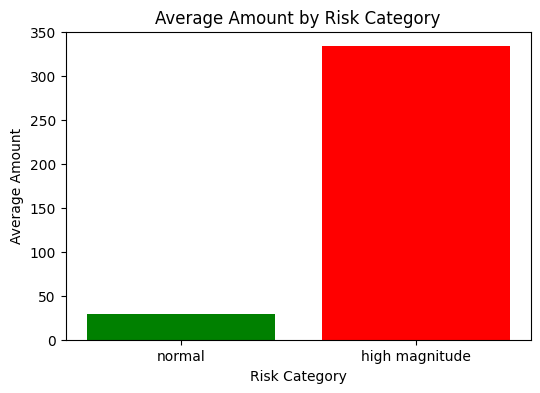

In [32]:
import duckdb
import matplotlib.pyplot as plt


df_chart = duckdb.sql("""
    SELECT risk_flag, AVG(amount) AS avg_transaction_amount
    FROM 'risk.csv'
    GROUP BY risk_flag;
""").df()


plt.figure(figsize=(6,4))
plt.bar(df_chart['risk_flag'], df_chart['avg_transaction_amount'], color=['green', 'red'])
plt.title('Average Amount by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Average Amount')
plt.show()

In [33]:
plt.savefig('risk_analysis_chart.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>